# Autograd - Demonstration

## Introduction

After doing many different machine learning projects, I decided I wanted a deeper understanding of the maths and algorithms behind libraries such as PyTorch, starting from the ground up. autograd.main is a library of functions and classes making up all the building blocks for a classification model (see the MNIST demo below) built using **only** NumPy. Each component is demonstrated briefly below; however, if you want to take a closer look, go to the main file, where the components are all well documented and the code is fairly readable.

Towards the end of this notebook, a full gradient descent loop is shown before a model already trained on the MNIST dataset is loaded and trained further, again exclusively using this library.

**Full disclosure**:
As someone who taught themselves how to code, I have used AI tools such as Gemini and ChatGPT to explain errors, help with syntax, and spot bugs I may have missed. However, I made sure not to blindly use their code, and **no** function was ever designed or fully created by anyone or anything other than myself.

## Library components

In [1]:
import numpy as np
import main

In [2]:
# These test inputs will be used throughout this notebook.
test_inputs = [
    np.array([-1, -0.5, 0, 1, 63.4]),
    [[0, 1, 2], [2, 0.7, -1]],
    (-2, -0.32, 0, 1, 0),
    "This is a string."
]

test_input_targets = [
    np.array([-3, -0.1, 0, 1, 1]),
    [[0, 1, 2], [3, 0.6, -1.1]],
    (2, -0.2, 5.6, 3, 2),
    "This is not a string."
]

In [3]:
# ReLU
for t in test_inputs:
    try:
        print(f"Input - {t} - Output - {main.ReLU(t)}")
    except:
        print(f"Input - {t} - cannot be passed through ReLU.")

Input - [-1.  -0.5  0.   1.  63.4] - Output - [ 0.   0.   0.   1.  63.4]
Input - [[0, 1, 2], [2, 0.7, -1]] - Output - [[0.  1.  2. ]
 [2.  0.7 0. ]]
Input - (-2, -0.32, 0, 1, 0) - Output - [0. 0. 0. 1. 0.]
Input - This is a string. - cannot be passed through ReLU.


In [4]:
# backwards_ReLU (the derivative of ReLU)
for t in test_inputs:
    try:
        print(f"Input - {t} - Output - {main.backwards_ReLU(t)}")
    except:
        print(f"Input - {t} - cannot be passed through backwards_ReLU.")

Input - [-1.  -0.5  0.   1.  63.4] - Output - [0. 0. 0. 1. 1.]
Input - [[0, 1, 2], [2, 0.7, -1]] - Output - [[0. 1. 1.]
 [1. 1. 0.]]
Input - (-2, -0.32, 0, 1, 0) - Output - [0. 0. 0. 1. 0.]
Input - This is a string. - cannot be passed through backwards_ReLU.


In [5]:
# Softmax
for t in test_inputs:
    try:
        print(f"Input - {t} - Output - {main.Softmax(t)}")
    except:
        print(f"Input - {t} - cannot be passed through Softmax.")

Input - [-1.  -0.5  0.   1.  63.4] - Output - [1.07506659e-28 1.77248515e-28 2.92233398e-28 7.94372734e-28
 1.00000000e+00]
Input - [[0, 1, 2], [2, 0.7, -1]] - Output - [[0.09003057 0.24472847 0.66524096]
 [0.75624725 0.20610142 0.03765133]]
Input - (-2, -0.32, 0, 1, 0) - Output - [0.02425465 0.13013969 0.17921898 0.4871677  0.17921898]
Input - This is a string. - cannot be passed through Softmax.


In [6]:
# CrossEntropyLoss
for i in range(len(test_inputs)):
    try:
        print(f"Input - {test_inputs[i]} - Target - {main.Softmax(test_input_targets[i])} - Output - {main.CrossEntropyLoss(main.Softmax(test_inputs[i]), main.Softmax(test_input_targets[i]))}")
    except:
        print(f"Input - {test_inputs[i]} - and Target - {test_input_targets[i]} - cannot be passed through CrossEntropyLoss.")

Input - [-1.  -0.5  0.   1.  63.4] - Target - [0.006736   0.1224211  0.13529624 0.36777332 0.36777332] - Output - 14.55755720585011
Input - [[0, 1, 2], [2, 0.7, -1]] - Target - [[0.09003057 0.24472847 0.66524096]
 [0.90310527 0.08192786 0.01496687]] - Output - 0.6315946608813265
Input - (-2, -0.32, 0, 1, 0) - Target - [0.02413866 0.00267464 0.88343236 0.06561568 0.02413866] - Output - 1.7026643902210021
Input - This is a string. - and Target - This is not a string. - cannot be passed through CrossEntropyLoss.


In [7]:
# Linear layer
test_layer = main.LinearLayer(input_size=3, output_size=1, precision='float32', random_seed=1)

print(f"Layer parameters - {test_layer.parameters}")
print()

for t in test_inputs:
    try:
        print(f"Input - {t} - Output - {test_layer.forward(t)}")
    except:
        print(f"Input - {t} - cannot be passed through the linear layer.")

# Most inputs fail because they have the wrong size for the model

Layer parameters - {'weights': array([[-0.054],
       [ 0.023],
       [ 0.51 ]], dtype=float32), 'biases': array([0.9], dtype=float32)}

Input - [-1.  -0.5  0.   1.  63.4] - cannot be passed through the linear layer.
Input - [[0, 1, 2], [2, 0.7, -1]] - Output - [[1.943 ]
 [0.2981]]
Input - (-2, -0.32, 0, 1, 0) - cannot be passed through the linear layer.
Input - This is a string. - cannot be passed through the linear layer.


## Demos

### Linear regression

In [8]:
x_axis_for_data = np.linspace(0, 10, 100)
inputs = np.asarray(np.split(x_axis_for_data, 100))
targets = inputs * 2.65 + 1.6

Simple = main.LinearLayer(input_size=1, output_size=1, precision='float32', random_seed=1)

mse_over_time = []
time = np.linspace(1, 10, 10)

print(f"Initial layer parameters - {Simple.parameters}.")

for i in range(10):
    x = Simple.forward(inputs)
    error = x - targets
    mse_over_time.append(np.mean(error ** 2.0))

    print(f"Epoch {i+1} - Mean error {-np.mean(error)}")

    # Gradient of loss with respect to output for MSE
    error_grad = (2.0 / inputs.shape[0]) * error

    Simple.backwards(error_grad)
    Simple.update_parameters(0.01)

print(f"Final layer parameters - {Simple.parameters}.")

Initial layer parameters - {'weights': array([[-0.054]], dtype=float32), 'biases': array([0.023], dtype=float32)}.
Epoch 1 - Mean error 15.097000005738808
Epoch 2 - Mean error 4.947704686820507
Epoch 3 - Mean error 1.7504245626926422
Epoch 4 - Mean error 0.7425506603717801
Epoch 5 - Mean error 0.42419038504362094
Epoch 6 - Mean error 0.32298430681228624
Epoch 7 - Mean error 0.29017101377248755
Epoch 8 - Mean error 0.27890172630548465
Epoch 9 - Mean error 0.27442312002181996
Epoch 10 - Mean error 0.272085176706314
Final layer parameters - {'weights': array([[2.8137128]], dtype=float32), 'biases': array([0.5110087], dtype=float32)}.


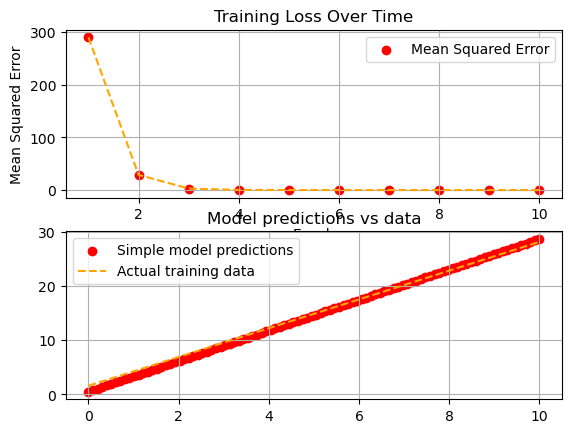

In [9]:
from matplotlib import pyplot as plt

model_preds = Simple.forward(inputs)

fig, axs = plt.subplots(2)

axs[0].scatter(x=time, y=mse_over_time, color='red', label='Mean Squared Error')
axs[0].plot(time, mse_over_time, color='orange', linestyle='--')

axs[0].set_title("Training Loss Over Time")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Mean Squared Error")
axs[0].grid(True)
axs[0].legend()


axs[1].scatter(x=x_axis_for_data, y=model_preds, color='red', label='Simple model predictions')
axs[1].plot(x_axis_for_data, targets.flatten(), color='orange', linestyle='--', label='Actual training data')

axs[1].set_title("Model predictions vs data")
axs[1].grid(True)
axs[1].legend()


plt.show()

### **MNIST** classification through gradient descent
In this section, a sample of the MNIST dataset is used to show how a model can be trained using this library. After a few iterations, to demonstrate the functionality of this library, a pretrained model (trained on a larger dataset using only this library) will be loaded to show more accurate classification while saving time and computation.

#### Setting up the data

In [10]:
from pandas import read_csv
from pathlib import Path

data_dir = Path("reduced_MNIST_data")

data_frame = read_csv(data_dir)
data_frame = data_frame.drop(columns=["Unnamed: 0"], errors="ignore")

data = data_frame.to_numpy()
m, n = data.shape

data_dev = data[0:200]
Y_dev = data_dev[:, 0].astype(int)
X_dev = data_dev[:, 1:].astype(np.float32) / 255.0

data_train = data[200:m]
Y_train = data_train[:, 0].astype(int)
X_train = data_train[:, 1:].astype(np.float32) / 255.0

print(X_train.shape)
print(Y_train.shape)
m_train, n_features = X_train.shape

def one_hot(Y):
    Y = np.asarray(Y, dtype=int)
    one_hot_Y = np.zeros((Y.size, Y.max() + 1), dtype=np.float32)
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y

Y_train = one_hot(Y_train)
Y_dev = one_hot(Y_dev)

print(X_train.shape)
print(Y_train.shape)

(370, 784)
(370,)
(370, 784)
(370, 10)


#### Creating and training a model

In [11]:
model = main.Model(input_size=784, output_size=10, hidden_size=64,
              number_of_layers=8, activation_function=main.ReLU, normalisation_function=main.Softmax,
              random_seed=11, initialisation_function="He")

In [15]:
for i in range(100):
    output = model.forward(X_train)
    loss = main.CrossEntropyLoss(output, Y_train)
    model.backwards(output, Y_train, main.CrossEntropyLoss)
    model.update_parameters(1e-2)
    if (i+1) % 10 == 0 or i == 0:
        print(f"Epoch: {i+1}    Loss: {round(loss, 5)}    Accuracy: {round(np.exp(-loss) * 100, 3)}%")
        dev_output = model.forward(X_dev)
        dev_loss = main.CrossEntropyLoss(dev_output, Y_dev)
        print(f"Validation loss: {round(dev_loss, 5)}    Accuracy: {round(np.exp(-dev_loss) * 100, 3)}%")

# Running this cell again will continue training the existing model to 200 epochs.


Epoch: 1    Loss: 2.88934    Accuracy: 5.561%
Validation loss: 2.53    Accuracy: 7.966%
Epoch: 10    Loss: 2.16207    Accuracy: 11.509%
Validation loss: 2.18143    Accuracy: 11.288%
Epoch: 20    Loss: 1.92972    Accuracy: 14.519%
Validation loss: 1.94325    Accuracy: 14.324%
Epoch: 30    Loss: 1.65648    Accuracy: 19.081%
Validation loss: 1.74213    Accuracy: 17.515%
Epoch: 40    Loss: 1.47483    Accuracy: 22.882%
Validation loss: 2.47066    Accuracy: 8.453%
Epoch: 50    Loss: 1.90895    Accuracy: 14.824%
Validation loss: 2.00467    Accuracy: 13.471%
Epoch: 60    Loss: 1.286    Accuracy: 27.637%
Validation loss: 1.81035    Accuracy: 16.36%
Epoch: 70    Loss: 0.94867    Accuracy: 38.725%
Validation loss: 1.20801    Accuracy: 29.879%
Epoch: 80    Loss: 1.04361    Accuracy: 35.218%
Validation loss: 1.21512    Accuracy: 29.667%
Epoch: 90    Loss: 1.09679    Accuracy: 33.394%
Validation loss: 2.12681    Accuracy: 11.922%
Epoch: 100    Loss: 6.26704    Accuracy: 0.19%
Validation loss: 6.0171

#### Showcasing the data from the model

In [18]:
print("Model parameters for Layer 3:")
print(model.parameters["Layer 3"])

print("Model gradients for Layer 3:")
print(model.gradients["Layer 3"])

Model parameters for Layer 3:
{'weights': array([[ 0.3184823 , -0.5492611 ,  0.1689742 , ...,  0.10537863,
        -0.10637777, -0.11525127],
       [ 0.22589812,  0.19594094,  0.08984049, ...,  0.06622064,
        -0.09763709, -0.17921396],
       [-0.0611458 , -0.07917526, -0.39015222, ...,  0.06997635,
         0.33431646,  0.06300572],
       ...,
       [-0.0393048 ,  0.20169419,  0.09938127, ...,  0.23476008,
        -0.28326777,  0.09490774],
       [ 0.08651959,  0.1936695 ,  0.16391292, ..., -0.10897063,
         0.26989385, -0.24742585],
       [ 0.3126758 ,  0.09876016,  0.01754832, ..., -0.13891807,
        -0.15479152,  0.01819343]], dtype=float32), 'biases': array([-0.3923983 , -0.09737756,  0.8849916 , -0.10423833, -0.35392216,
        0.5679502 ,  0.922634  , -0.83150107, -0.8976598 ,  0.72907275,
        0.88108385,  0.16130409, -0.79651535,  0.86537224, -0.5372795 ,
        0.4896578 ,  0.64609975, -0.5177715 , -0.89699775, -0.75568897,
       -0.2562827 ,  0.9367868 

#### Loading a pretrained model

In [11]:
from pickle import load
saved_model = main.Model(input_size=784, output_size=10, hidden_size=128,
              number_of_layers=4, activation_function=main.ReLU, normalisation_function=main.Softmax,
              random_seed=0, initialisation_function="He")


parameters_path = Path("pretrained_model_parameters.pkl")

with parameters_path.open("rb") as file:
    loaded_parameters = load(file)

saved_model.set_parameters(loaded_parameters)
print("Retrieved saved model")

Retrieved saved model


In [14]:
# Displaying the saved model's loss and accuracy
train_output = saved_model.forward(X_train)
train_loss = main.CrossEntropyLoss(train_output, Y_train)

train_predictions = np.argmax(train_output, axis=1)
train_targets = np.argmax(Y_train, axis=1)
train_accuracy = np.mean(train_predictions == train_targets) * 100

# The same as above for the validation set
val_output = saved_model.forward(X_dev)
val_loss = main.CrossEntropyLoss(val_output, Y_dev)

val_predictions = np.argmax(val_output, axis=1)
val_targets = np.argmax(Y_dev, axis=1)
val_accuracy = np.mean(val_predictions == val_targets) * 100

# Printing the results of the current epoch
print(
    f"Train Loss: {round(train_loss, 2)} | Train Acc: {round(train_accuracy, 3)}% | "
    f"Val Loss: {round(val_loss, 3)} | Val Acc: {round(val_accuracy, 3)}%"
    )   

Train Loss: 0.35 | Train Acc: 90.0% | Val Loss: 0.3 | Val Acc: 92.5%


#### Visual demonstration

Prediction: 1    Label: 1


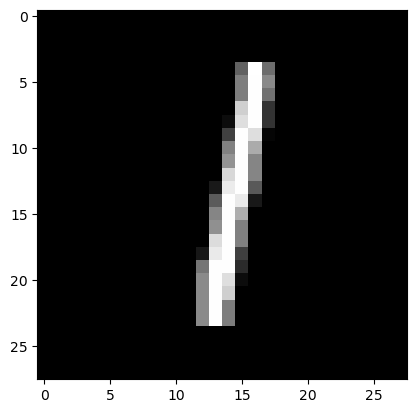

Prediction: 6    Label: 6


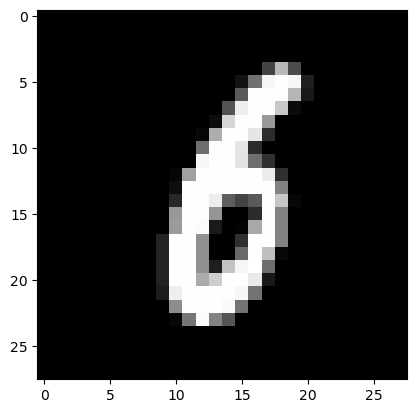

Prediction: 4    Label: 4


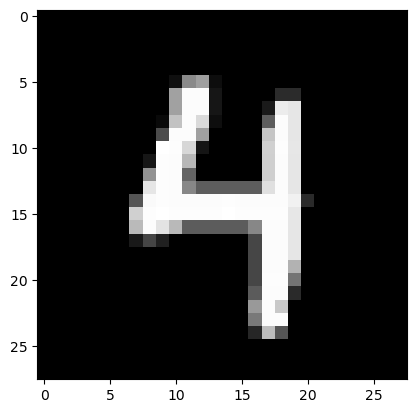

Prediction: 2    Label: 2


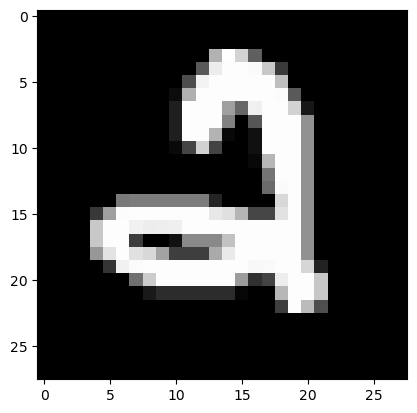

In [16]:
def show_prediction(index : int):
    current_image = X_dev[index:index + 1, None]
    probs = saved_model.forward(current_image)
    prediction = np.argmax(probs)
    label = np.argmax(Y_dev[index])
    print(f"Prediction: {prediction}    Label: {label}")

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

for _ in range(4):
    index = np.random.randint(0, 199)
    show_prediction(index)

## Final thoughts

This library is not very sophisticated or expansive; however, the initial task of creating a system of interconnected functions has been completed, and so it would take only a few minutes to add more components such as:
- A wider variety of activation and normalisation functions
- Averaged gradients over time, reducing the chance of getting stuck at a local minimum
- More initialisation functions for the LinearLayers
- etc.

Regardless, the aim of this project was to understand the maths behind gradient descent, not to create the best library in existence, and that aim has been achieved.

## Acknowledgements and Resources

A huge thanks to the following creators for their resources and explanations:

- 3Blue1Brown for all his videos, particularly the first four in his "Neural Networks" series.
    - https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi

- CodeEmporium for his "Backpropagation by hand" video.
    - https://www.youtube.com/watch?v=12-HUfbyGso&list=WL&index=4&t=1022s

- Samson Zhang for his tutorial "Building a neural network FROM SCRATCH," which first introduced me to ML.
    - https://www.youtube.com/watch?v=w8yWXqWQYmU


As someone who taught themselves how to code, the following were very useful both in this project and others:

- GeeksforGeeks.org for its explanations and examples for Python and common Python libraries.
    - https://www.geeksforgeeks.org/

- As mentioned above, AI tools such as Gemini and ChatGPT were used to explain errors, help with syntax, and spot bugs I may have missed. However, I made sure not to blindly use their code, and **no** function was ever designed or fully created by anyone or anything other than myself.